# Model Results and Biological Interpretation

This notebook summarizes the binary TP53 classifier, the mutation-type classifier, and the p53 biology interpretation outputs.

In [1]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

## Binary Classification: TP53 Mutant vs Wild-Type

In [2]:
binary_val = pd.read_csv("reports/tables/binary_validation_performance.csv")
binary_val.sort_values("roc_auc", ascending=False).head(10)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,feature_set,model,split
0,0.899225,0.887407,0.878049,0.960000,0.917197,0.916667,0.890837,p53_pathway,random_forest,validation
1,0.844961,0.842037,0.871622,0.860000,0.865772,0.916296,0.924605,p53_pathway,elastic_net_logistic,validation
2,0.895349,0.882778,0.872727,0.960000,0.914286,0.915432,0.892152,p53_pathway,extra_trees,validation
3,0.856589,0.853333,0.879195,0.873333,0.876254,0.913889,0.918921,p53_pathway,logistic_l2,validation
4,0.852713,0.842222,0.850000,0.906667,0.877419,0.913827,0.918073,top_3000_variable,hist_gradient_boosting,validation
5,0.856589,0.853333,0.879195,0.873333,0.876254,0.912346,0.916205,p53_pathway,linear_svm,validation
6,0.844961,0.836852,0.852564,0.886667,0.869281,0.912037,0.920403,tp53_targets,elastic_net_logistic,validation
7,0.848837,0.841481,0.858065,0.886667,0.872131,0.911235,0.921827,tp53_targets,logistic_l2,validation
8,0.895349,0.882778,0.872727,0.960000,0.914286,0.910802,0.892595,tp53_targets,extra_trees,validation
9,0.852713,0.843519,0.854430,0.900000,0.876623,0.909506,0.918683,tp53_targets,linear_svm,validation


In [3]:
pd.read_csv("reports/tables/binary_test_performance.csv")

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,feature_set,model,split
0,0.829457,0.811852,0.811765,0.92,0.8625,0.905617,0.919551,p53_pathway,random_forest,test


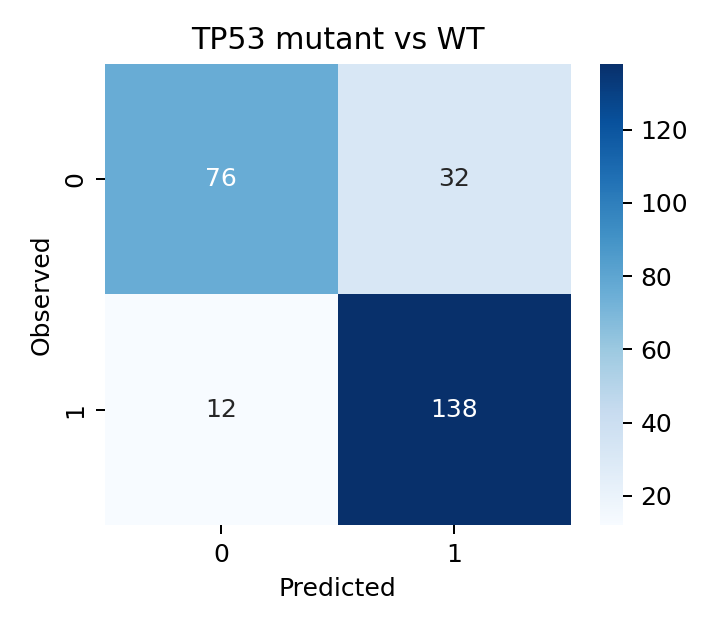

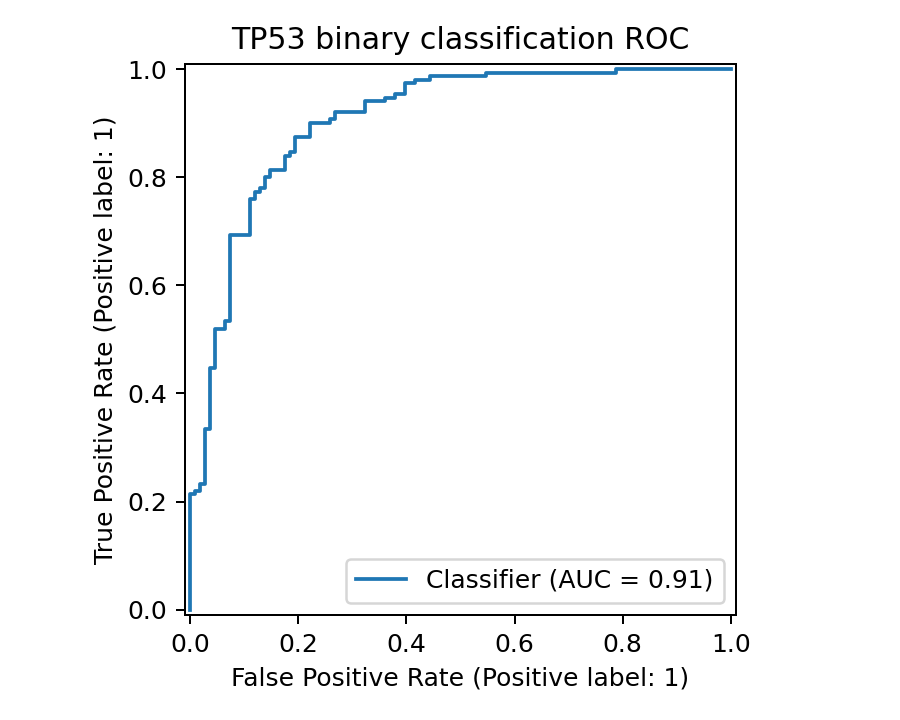

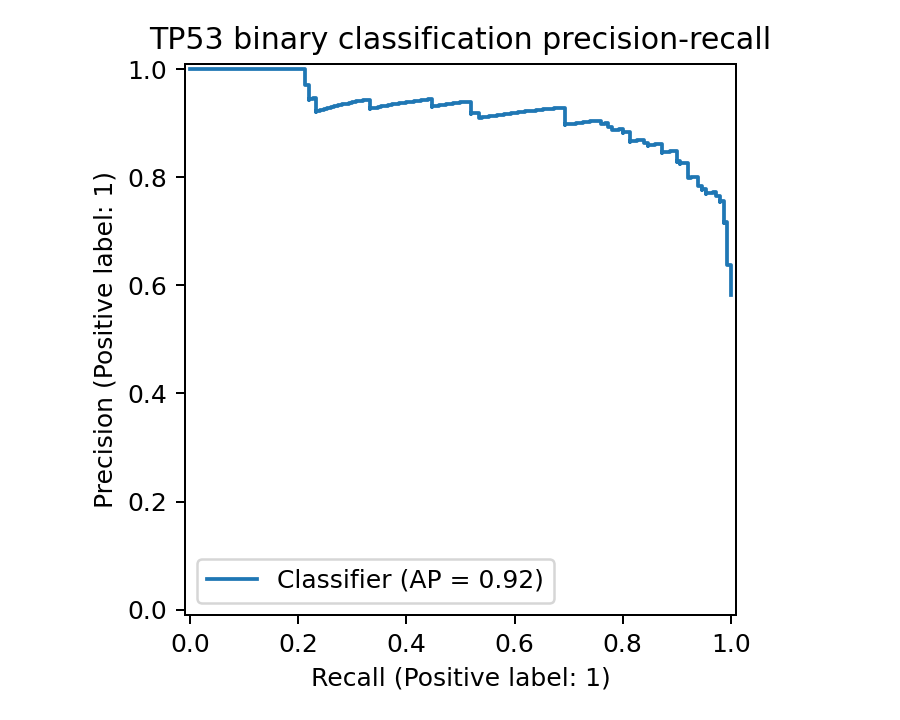

In [4]:
display(Image(filename="reports/figures/binary_confusion_matrix.png"))
display(Image(filename="reports/figures/binary_best_model_roc.png"))
display(Image(filename="reports/figures/binary_best_model_pr.png"))

## Mutation-Type Classification

In [5]:
multi_val = pd.read_csv("reports/tables/multiclass_validation_performance.csv")
multi_val.sort_values("macro_f1", ascending=False).head(10)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,feature_set,model,split
0,0.714844,0.480634,0.480674,0.698071,tp53_targets,random_forest,validation
1,0.703125,0.449276,0.455723,0.680030,tp53_targets,extra_trees,validation
2,0.726562,0.450986,0.451582,0.699825,p53_pathway,random_forest,validation
3,0.609375,0.447681,0.429592,0.634450,p53_pathway,logistic_l2,validation
4,0.683594,0.383772,0.378107,0.644039,p53_pathway,extra_trees,validation
5,0.562500,0.360564,0.365997,0.596566,tp53_targets,logistic_l2,validation
6,0.574219,0.332800,0.331396,0.561768,top_3000_variable,logistic_l2,validation
7,0.597656,0.302516,0.267498,0.532141,top_3000_variable,random_forest,validation
8,0.582031,0.293913,0.260277,0.517834,top_3000_variable,extra_trees,validation
9,0.425781,0.200000,0.119452,0.254302,top_3000_variable,majority,validation


In [6]:
pd.read_csv("reports/tables/multiclass_test_performance.csv")

,accuracy,balanced_accuracy,macro_f1,weighted_f1,feature_set,model,split
0,0.714844,0.449211,0.447827,0.690331,tp53_targets,random_forest,test


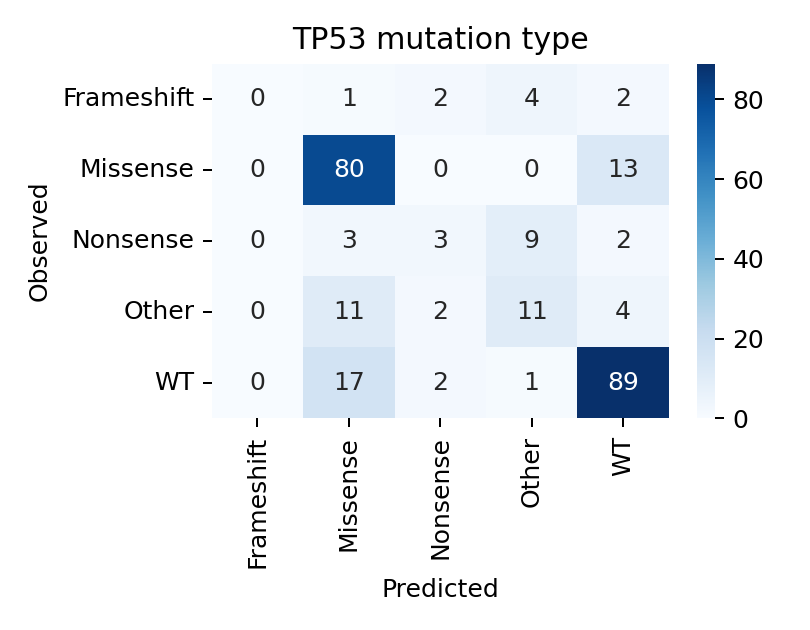

In [7]:
display(Image(filename="reports/figures/multiclass_confusion_matrix.png"))

## Important Genes and Biological Overlap

In [8]:
pd.read_csv("reports/tables/binary_best_model_top_genes.csv").head(20)

,gene,importance,abs_importance
0,MDM2,0.090885,0.090885
1,ZMAT3,0.073021,0.073021
2,CDKN1A,0.071180,0.071180
3,BAX,0.040709,0.040709
4,SESN1,0.038744,0.038744
5,RRM2B,0.034256,0.034256
6,SFN,0.030193,0.030193
7,TNFRSF10B,0.026597,0.026597
8,PHLDA3,0.025578,0.025578
9,DRAM1,0.023507,0.023507


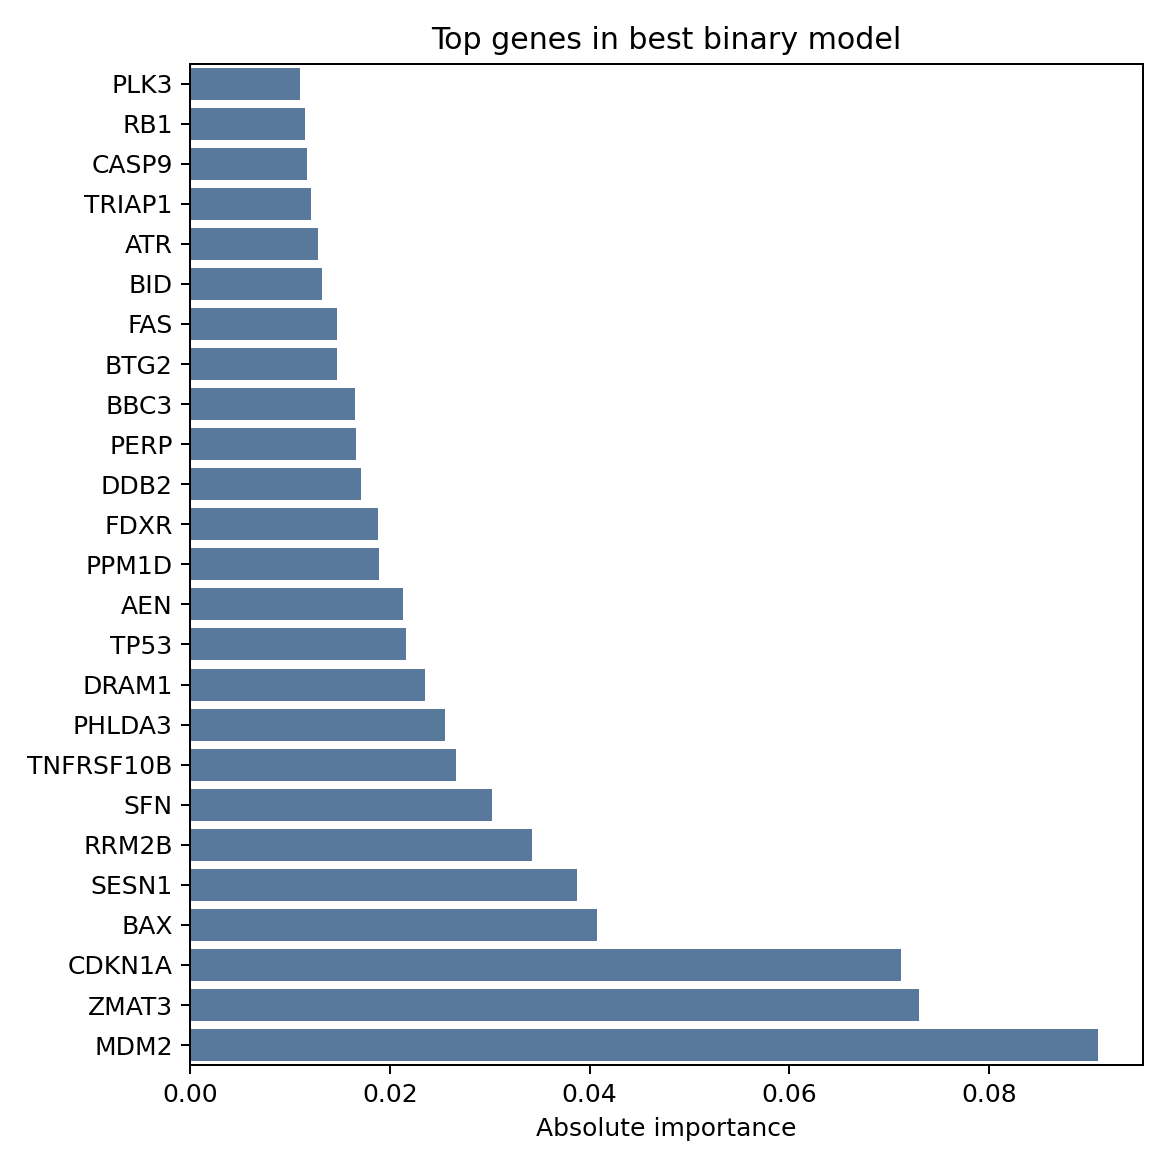

In [9]:
display(Image(filename="reports/figures/binary_top_genes.png"))

In [10]:
pd.read_csv("reports/tables/biological_overlap_summary.csv")

,gene_set,overlap_count,genes
0,TP53 direct targets in top differential genes,16,AEN;BAX;BBC3;CDKN1A;DDB2;DRAM1;FAS;FDXR;MDM2;PHLDA3;RRM2B;SESN1;SFN;TNFRSF10B;TRIAP1;ZMAT3
1,p53 pathway genes in top differential genes,16,AEN;BAX;BBC3;CDKN1A;DDB2;DRAM1;FAS;FDXR;MDM2;PHLDA3;RRM2B;SESN1;SFN;TNFRSF10B;TRIAP1;ZMAT3
2,TP53 direct targets,33,AEN;APAF1;BAX;BBC3;BTG2;CASP1;CD82;CDKN1A;DDB2;DRAM1;EI24;FAS;FDXR;GADD45A;MDM2;PANK1;PERP;PHLDA3;PLK3;PMAIP1;PPM1D;...
3,p53 pathway,62,AEN;APAF1;ATM;ATR;BAK1;BAX;BBC3;BCL2;BCL2L1;BID;BRCA1;BRCA2;BTG2;CASP1;CASP3;CASP8;CASP9;CCND1;CCNE1;CD82;CDK2;CDK4;...


In [11]:
de = pd.read_csv("reports/tables/differential_expression_tp53_mutant_vs_wt.csv")
de.head(20)

,gene,mean_mutant,mean_wt,difference_mutant_minus_wt,p_value,rank_p,fdr_bh
0,EDA2R,0.369827,2.163987,-1.794160,3.925008e-131,1.0,7.541902e-127
1,RPS27L,6.404370,7.578244,-1.173874,1.666730e-113,2.0,1.601310e-109
2,CDKN1A,4.700432,6.641905,-1.941473,3.580774e-107,3.0,2.293486e-103
3,MDM2,4.711485,6.031187,-1.319702,9.551311e-98,4.0,4.588211e-94
4,ZMAT3,2.701493,3.906226,-1.204732,8.649890e-97,5.0,3.324153e-93
5,BAX,6.600468,7.253759,-0.653291,5.261418e-67,6.0,1.684969e-63
6,RRM2B,3.959146,4.790120,-0.830974,5.681072e-65,7.0,1.559454e-61
7,SESN1,2.827146,3.695974,-0.868828,1.653752e-63,8.0,3.972107e-60
8,DDB2,4.472230,5.182435,-0.710205,2.359904e-52,9.0,5.038396e-49
9,SPATA18,0.354450,1.204454,-0.850004,2.699473e-52,10.0,5.187037e-49
